In [1]:
import sys

In [2]:
%%capture
try:
    # Attempt to import a module that's only available in Colab
    from google.colab import drive

    in_colab = True
except ImportError:
    in_colab = False

if in_colab:
    # Colab specific setup
    drive.mount("/content/drive")
    sys.path.append("/content/drive/MyDrive/structure-loss-classification/")
    my_local_data = "/content/drive/MyDrive/types/"
    %cd '/content/drive/MyDrive/structure-loss-classification/'
    %pip install -r requirements.txt
else:
    # Local machine setup
    my_local_data = "/mnt/g/My Drive/types/"

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay
import torchvision.transforms as transforms
import torch
from sklearn.model_selection import train_test_split

In [4]:
import pickle

In [5]:
from models.models import LeNet5, ResNet18
from lightning_modules.lightning_modules import LitLeNet5, LitResNet18, LitVGG16
from visualization.filters import display_filters
from visualization.display import process_plot_image, display_metrics
from datasets.data_modules import CustomImageDataModule
from train.train import get_features, train_model, train_with_cv
from hyperparameter_tuning.tune import HyperParameterTuner
from datasets.datasets import CustomDatasetWrapper
from utils.utils import load_targets, get_stat_metrics, get_train_val_data

In [6]:
toTensorAndNormalize = transforms.Compose(
    [
        transforms.Resize((244, 244)),
        transforms.RandomHorizontalFlip(),
        # transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # mean  # std
    ]
)

In [7]:
classification_mode = "all"

In [8]:
task = {"binary": 2, "only_bad": 3, "all": 4}

In [9]:
num_classes = task[classification_mode]

In [10]:
aux_data = CustomDatasetWrapper(
    root_dir=my_local_data,
    classification_mode=classification_mode,
    transform=toTensorAndNormalize,
)

In [11]:
# Try to load cached targets first
targets = load_targets(aux_data)

In [12]:
# Assuming aux_data is a dataset object and targets are the labels
train_data, val_data = get_train_val_data(aux_data, targets)

In [13]:
data_module = CustomImageDataModule(
    train_dataset=train_data,
    val_dataset=val_data,
    batch_size=32,
    num_workers=12,
)

In [14]:
aux_data.classes

['goodIngots', 'typeA', 'typeB', 'typeC']

### Test train

In [15]:
torch.set_float32_matmul_precision("medium")

In [16]:
from train.train import incremental_training

In [17]:
model_class = LitVGG16

In [18]:
model_params = {
    "num_classes": num_classes,
    "size_layer_1": 128,
    "size_layer_2": 64,
    "size_layer_3": 32,
    "learning_rate": 8.479282111072422e-05,
}

In [19]:
trainer_config = {
    "patience": 50,
    "accelerator": "gpu",
    "devices": -1,
    # "max_epochs": 100,
    "precision": 32,
    "n_steps": 5,
    "save_dir": f"logdir/LitVGG16/{classification_mode}",
}

In [20]:
# metrics = incremental_training(
#     model_class=model_class,
#     model_params=model_params,
#     trainer_config=trainer_config,
#     data_module=data_module,
#     early_stop_patience=5,

# )

In [21]:
from torchvision.models.feature_extraction import get_graph_node_names

In [22]:
from models.models import ResNet18

In [23]:
model = LeNet5(num_classes=num_classes,)
model = model.to("cuda")

In [24]:
# get_graph_node_names(model)[0]

In [25]:
# layers = [e for e in get_graph_node_names(model)[0] if 'pool' in e]
layers = [
    "convStack.1",
    "convStack.2",
    "convStack.3",
]

In [26]:
features, labels = get_features(
    model=model,
    layers=layers,
    data_loader=aux_data,
    device="cuda",
    classification_mode=classification_mode,
)

Attempting to load cached features and labels...
Loaded features and labels from cache.


In [27]:
import matplotlib.pyplot as plt

In [28]:
from visualization.filters import display_filters

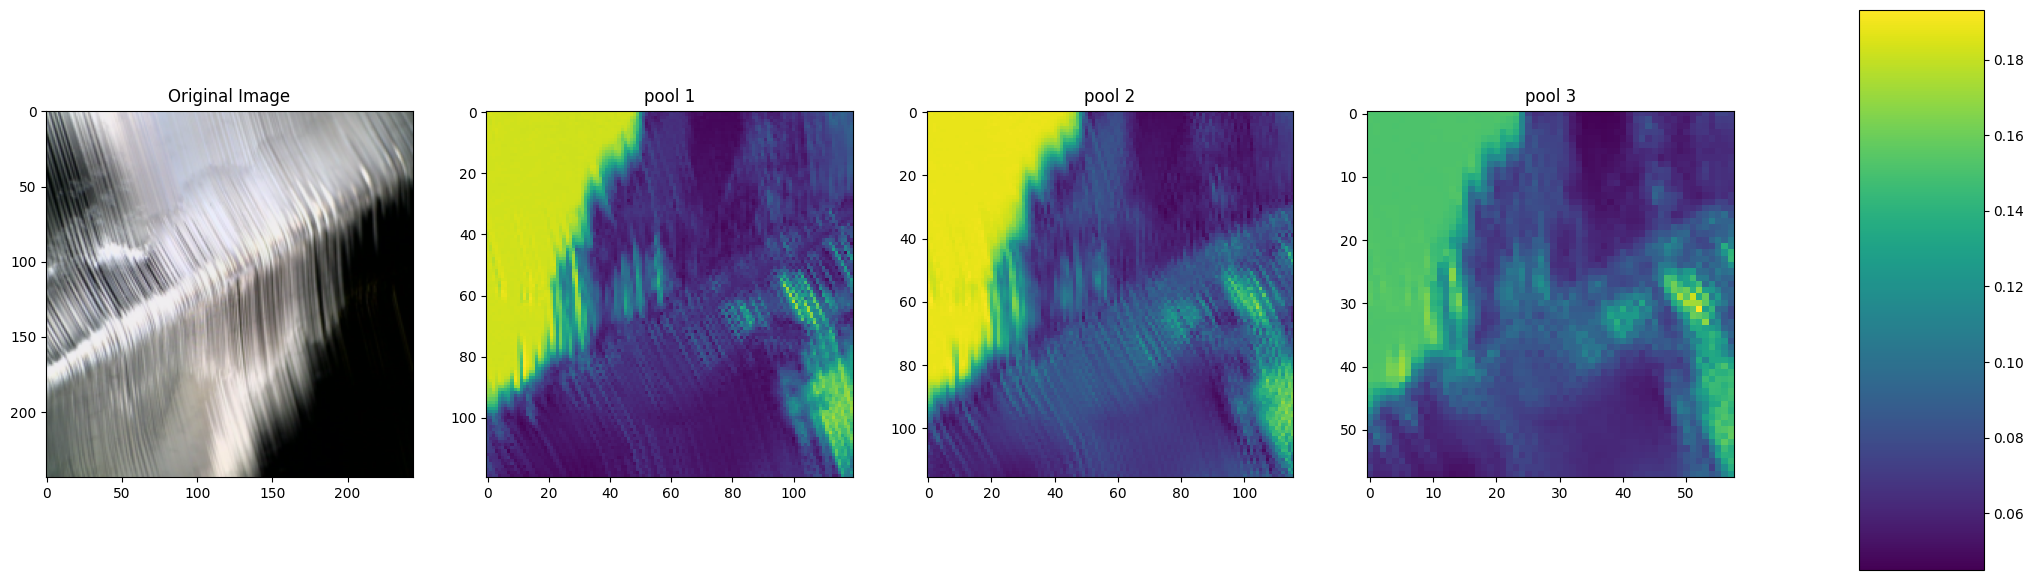

In [29]:
display_filters(
    features=features,
    img_num=33,
    layers=layers,
    cmap="viridis",
    name_layers=["pool 1", "pool 2", "pool 3"],
    data=aux_data,
)

In [30]:
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [31]:
import numpy as np

In [32]:
for layer_name in features:
    features[layer_name] = [feature.flatten() for feature in features[layer_name]]

In [33]:
hp_sweep = {
    "kernel": "rbf",
    "C": 3.2010661148711947,
    "gamma": "scale",
    "features_index": 1,
}

In [34]:
def display_cm(cm, labels, filename):
    """
    Display and save the confusion matrix as a PDF.

    :param cm: The confusion matrix.
    :param labels: The labels for the classes.

    """

    # Create the ConfusionMatrixDisplay object
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

    # Create a new figure for the confusion matrix
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the confusion matrix and customize the appearance
    cm_display.plot(ax=ax, cmap="viridis")

    # Save the confusion matrix as a PDF
    # plt.savefig(f'drive/MyDrive/NSCC/VGG16/{filename}.pdf', bbox_inches='tight')

    # Display the confusion matrix
    plt.show()

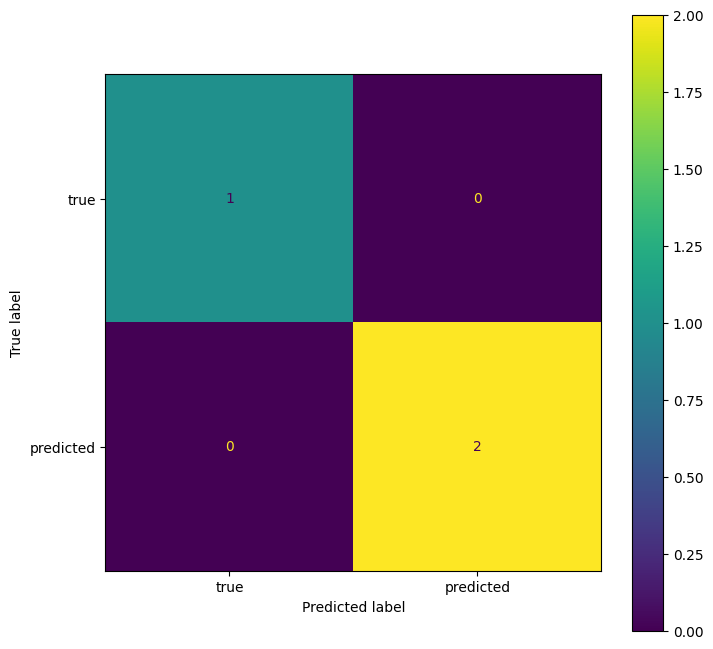

In [35]:
display_cm(np.array([[1, 0], [0, 2]]), labels=["true", "predicted"], filename=None)

In [36]:
# Use the first layer's features in this example
X = np.array(features[layers[hp_sweep["features_index"]]])
y = np.array(labels)

# Initialize the 5-fold cross-validator
cv = StratifiedKFold(n_splits=5)

# Create an SVC with an RBF kernel
# svc = SVC(kernel=hp_sweep['kernel'],
#           C=hp_sweep['C'],
#           gamma=hp_sweep['gamma'])

svc = SVC()

# Initialize an empty confusion matrix to store the summary of all folds
summary_confusion_matrix = np.zeros((len(np.unique(y)), len(np.unique(y))))
accuracies = []

In [37]:
aux_data.classes

['goodIngots', 'typeA', 'typeB', 'typeC']

In [38]:
names_dict = {
    "typeA": "Diameter\nFluctuations",
    "typeB": "Node Cut",
    "typeC": "Particle Hit",
    "goodIngots": "No Structure\nLoss",
}

# Get class indices from the ImageFolder
class_indices = aux_data.classes

# Order your names list according to the class indices
names = [names_dict[class_name] for class_name in aux_data.classes]

In [39]:
names

['No Structure\nLoss', 'Diameter\nFluctuations', 'Node Cut', 'Particle Hit']

In [40]:
for count, (train_index, test_index) in enumerate(cv.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Train the SVC on the training data
    svc.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = svc.predict(X_test)

    # Compute the confusion matrix for this fold
    cm = confusion_matrix(y_test, y_pred)

    acc = accuracy_score(y_test, y_pred)

    # Add the confusion matrix of this fold to the summary confusion matrix
    summary_confusion_matrix += cm
    accuracies.append(acc)

    # Print the confusion matrix and accuracy for this fold
    print(f"Accuracy for fold {count}: {acc}")


# Print the summary confusion matrix for all folds and the average accuracy
print("\nSummary confusion matrix for all folds:\n", summary_confusion_matrix)
display_cm(summary_confusion_matrix, names, "summary")
print(f"\nAverage accuracy for all folds: {np.mean(accuracies)}")

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dfs = []

In [ ]:
dfs

In [ ]:
for folder in sorted(glob.glob("logdir/all/lightning_logs/*")):
    df = pd.read_csv(f"{folder}/metrics.csv")
    dfs.append(df)

In [ ]:
dfs

In [1]:
from hyperparameter_tuning.tune import tune_classification

In [ ]:
for c, df in enumerate(dfs):
    plt.plot(df.epoch, df.val_accuracy, "o:", label=c + 1)
    if c > 0:
        previous_df = dfs[c - 1]
        # Get the last point of the previous dataframe and the first point of the current dataframe
        x_values = [previous_df.epoch.iloc[-1], df.epoch.iloc[0]]
        y_values = [previous_df.val_accuracy.iloc[-1], df.val_accuracy.iloc[0]]
        # Plot with dotted lines
        plt.plot(x_values, y_values, "o-", color="grey")
    plt.legend()

In [ ]:
# ConfusionMatrixDisplay(np.array(cm)).plot()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "notebook", "grid"])

In [ ]:
df = pd.read_csv(
    "/mnt/g/My Drive/structure-loss-classification/results/LitResNet18-not-pretrained/all.csv"
)
# df2 = pd.read_csv('/mnt/g/My Drive/structure-loss-classification/results/LitResNet18/all.csv')

In [ ]:
plt.figure(figsize=(10, 8))

plt.plot(df.epoch, df.mean_val_loss, label="validation loss - not pretrained")
plt.plot(df.epoch, df.mean_val_accuracy, label="validation accuracy - not pretrained")

plt.fill_between(
    df.epoch,
    df.mean_val_loss + df.std_val_loss,
    df.mean_val_loss - df.std_val_loss,
    alpha=0.2,
)
plt.fill_between(
    df.epoch,
    df.mean_val_accuracy + df.std_val_accuracy,
    df.mean_val_accuracy - df.std_val_accuracy,
    alpha=0.2,
)
plt.ylim(0, 3)
# plt.xlim(0,52)

plt.legend()

In [ ]:
[max(df2.mean_val_accuracy), max(df.mean_val_accuracy)]

In [ ]:
def compare_resnet18(
    classification_mode: str, dir_not: str, dir_pre: str, save: bool = False
):
    df = pd.read_csv(f"{dir_not}/{classification_mode}.csv")
    df_pre = pd.read_csv(f"{dir_pre}/{classification_mode}.csv")

    plt.figure(figsize=(10, 8))

    plt.plot(df.epoch, df.mean_val_loss, label="validation loss - not pretrained")
    plt.plot(
        df.epoch, df.mean_val_accuracy, label="validation accuracy - not pretrained"
    )

    plt.fill_between(
        df.epoch,
        df.mean_val_loss + df.std_val_loss,
        df.mean_val_loss - df.std_val_loss,
        alpha=0.2,
    )
    plt.fill_between(
        df.epoch,
        df.mean_val_accuracy + df.std_val_accuracy,
        df.mean_val_accuracy - df.std_val_accuracy,
        alpha=0.2,
    )
    plt.ylim(0, 1.4)
    # plt.xlim(12,52)

    plt.plot(df_pre.epoch, df_pre.mean_val_loss, label="validation loss - pretrained")
    plt.plot(
        df_pre.epoch, df_pre.mean_val_accuracy, label="validation accuracy - pretrained"
    )

    plt.fill_between(
        df_pre.epoch,
        df_pre.mean_val_loss + df_pre.std_val_loss,
        df_pre.mean_val_loss - df_pre.std_val_loss,
        alpha=0.2,
    )
    plt.fill_between(
        df_pre.epoch,
        df_pre.mean_val_accuracy + df_pre.std_val_accuracy,
        df_pre.mean_val_accuracy - df_pre.std_val_accuracy,
        alpha=0.2,
    )

    plt.legend()
    plt.xlabel("Epoch")

    if save:
        plt.savefig(
            f"/mnt/g/My Drive/structure-loss-classification/results/ResNet18_{classification_mode}.pdf",
            bbox_inches="tight",
        )

In [ ]:
dir_pre = "/mnt/g/My Drive/structure-loss-classification/results/LitResNet18/"
dir_not = (
    "/mnt/g/My Drive/structure-loss-classification/results/LitResNet18-not-pretrained"
)

In [ ]:
compare_resnet18("only_bad", dir_pre=dir_pre, dir_not=dir_not)

In [ ]:
compare_resnet18("binary", dir_pre=dir_pre, dir_not=dir_not)

In [ ]:
compare_resnet18("all", dir_pre=dir_pre, dir_not=dir_not)